#OBJECTIVE:

The objective of this project is to predict whether a loan application will be approved or not based on applicant demographic, income, credit history, and loan-related features.

#IMPORT LIBRARIES & LOAD DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_csv("LOAN APPROVAL PREDICTION.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


#BASIC DATA UNDERSTANDING

In [ ]:
# Shape of dataset
df.shape

(614, 13)

In [ ]:
# Column info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
# Statistical summary
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


By checking the shape and data types, I understood the scale of the dataset and the mix of numerical and categorical variables.

This step helps confirm that the problem is suitable for supervised learning and highlights the need for preprocessing steps like encoding and scaling.

#MISSING VALUE ANALYSIS

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


Missing values are present in both numerical and categorical features.

Since SVM cannot handle null values, treating missing data is mandatory to avoid biased learning and runtime errors.

#TARGET VARIABLE ANALYSIS

In [ ]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


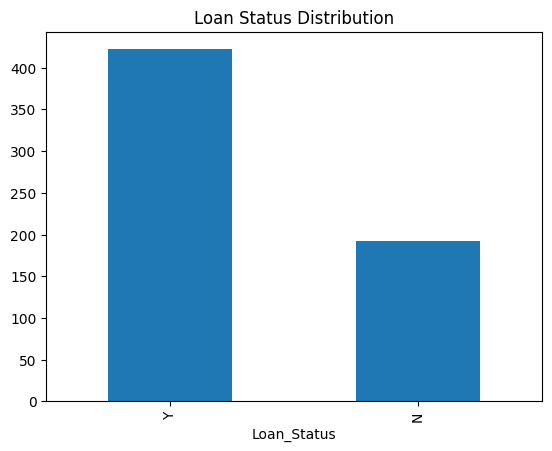

In [ ]:
df['Loan_Status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution")
plt.show()

The target distribution shows that approved loans are more frequent than rejected ones.

This class imbalance means that accuracy alone is not a reliable metric, and evaluation should focus on precision, recall, and F1-score.

#Applicant Income Distribution

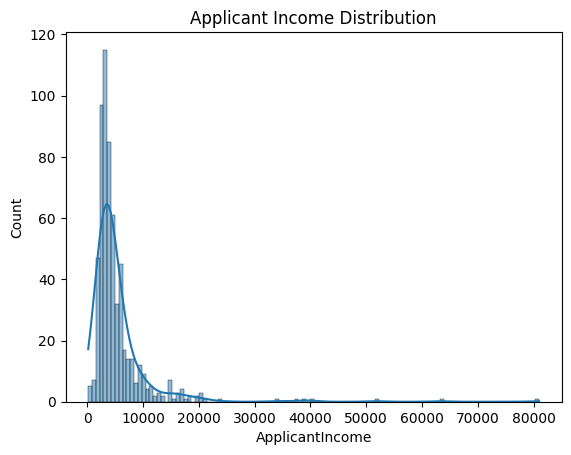

In [ ]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

The distribution is right-skewed, meaning most applicants have moderate incomes while a few earn significantly more.

Such skewness can distort distance-based models like SVM, which is why scaling becomes a crucial preprocessing step.

#Loan Amount Distribution

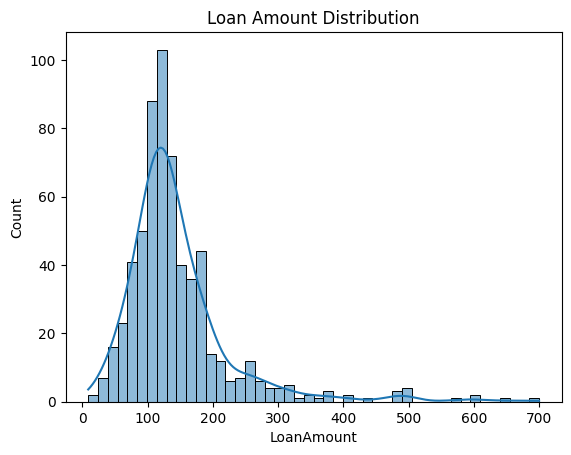

In [ ]:
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

Loan amounts also show right skewness, indicating the presence of high-value loan requests.

This pattern suggests that loan size alone is not sufficient for approval and must be considered alongside credit and income features.

#Credit History vs Loan Status

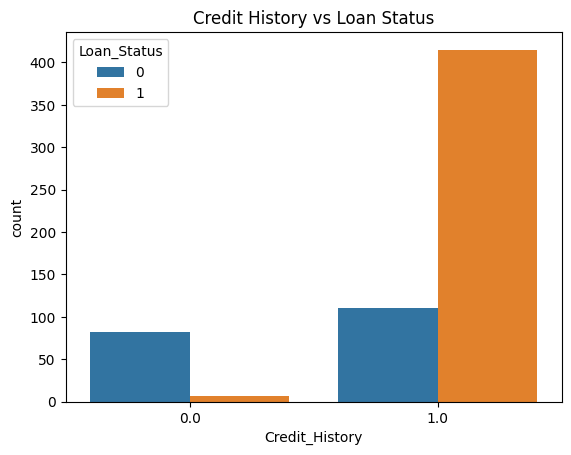

In [ ]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

This plot clearly indicates that applicants with a positive credit history have a much higher approval rate.

It confirms that credit history is the strongest predictor, aligning with real-world banking decisions.

#DATA PREPROCESSING-Handling Missing Values

In [ ]:
# Fill categorical missing values with mode (safe assignment)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Fill numerical missing values with median (safe assignment)
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())


Using median for numerical features minimizes the impact of outliers, while mode preserves the most frequent category for categorical features.

This ensures data consistency without introducing artificial bias.

#ENCODING CATEGORICAL VARIABLES

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Gender','Married','Dependents','Education',
                    'Self_Employed','Property_Area','Loan_Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


Since SVM requires numerical inputs, categorical variables were encoded.

Label encoding works well here because most features are binary or limited-category variables, keeping the model simple and interpretable.

#FEATURE & TARGET SPLIT

In [ ]:
X = df.drop(['Loan_ID','Loan_Status'], axis=1)
y = df['Loan_Status']

Separating features and the target variable clearly defines the supervised learning setup.

Removing non-informative columns like Loan_ID prevents noise from entering the model.

#FEATURE SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Scaling ensures all features contribute equally to the distance calculations used by SVM.

Without scaling, features like income would dominate the decision boundary, leading to poor generalization.

#TRAIN–TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

Splitting the data into training and testing sets helps evaluate how well the model performs on unseen data.

This step ensures that model performance reflects real-world predictive capability rather than memorization.

#SVM MODEL BUILDING

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train, y_train)

SVC(C=1)

#MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = svm_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7886178861788617

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



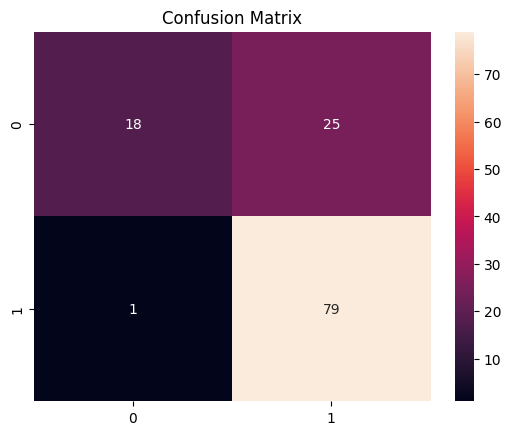

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows how effectively the model differentiates between approved and rejected loans.

Precision reflects the reliability of approvals, recall measures how many eligible applicants are correctly approved, and the F1-score balances both — which is critical in financial decision systems.

#FINAL TAKEAWAYS

This project demonstrates how applicant financial and credit-related features influence loan approval decisions.

SVM performed well after proper preprocessing and scaling, highlighting the importance of feature engineering.

Credit history emerged as the strongest predictor, while income and loan amount played supporting roles.